# Text Analytics Coursework (Group 37 - Task 2)



# 4) Preliminary Clustering

In [1]:
# 02 - CLUSTERING

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
# # Load the standardised dataset
df_raw = pd.read_csv("../outputs_SB/sentence_records_df.csv")

# Rename columns to match our clustering code
df = df_raw.rename(columns={
    "sentence_text": "sentence",
    "gold_label":    "label"
})

# Map label names to simple format
label_map = {
    "P": "participants",
    "I": "interventions",
    "O": "outcomes",
    "NONE": "none",
    "MIXED": "mixed"
}

df["label"] = df["label"].map(label_map)

print(f" Loaded {len(df)} sentences from standardised dataset")
print(f"\nLabel distribution:")
print(df["label"].value_counts())
print(f"\nColumns: {list(df.columns)}")

 Loaded 42481 sentences from standardised dataset

Label distribution:
label
mixed            12662
outcomes         10669
none             10360
interventions     5966
participants      2824
Name: count, dtype: int64

Columns: ['doc_id', 'sentence_id', 'sentence_start', 'sentence_end', 'sentence', 'sentence_tokens', 'p_count', 'i_count', 'o_count', 'label']


In [3]:
# STEP 1 - TF-IDF REPRESENTATION
print(" Converting sentences to TF-IDF vectors...")

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=3000,    # only keep top 3000 most important words
    stop_words="english", # remove common words like "the", "a", "is"
    ngram_range=(1, 2),   # use single words AND pairs of words
    min_df=5              # ignore words that appear in less than 5 sentences
)

# Convert sentences to numbers
sentences = df["sentence"].tolist()
tfidf_matrix = tfidf.fit_transform(sentences)

print(f" TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"   → {tfidf_matrix.shape[0]} sentences")
print(f"   → {tfidf_matrix.shape[1]} features (unique words/phrases)")

# Show most important words overall
feature_names = tfidf.get_feature_names_out()
print(f"\n Sample features (words/phrases):")
print(feature_names[:20])

 Converting sentences to TF-IDF vectors...
 TF-IDF matrix shape: (42481, 3000)
   → 42481 sentences
   → 3000 features (unique words/phrases)

 Sample features (words/phrases):
['00' '000' '0001' '001' '002' '003' '004' '005' '006' '007' '008' '01'
 '02' '03' '04' '05' '06' '07' '08' '09']


In [4]:
# STEP 2 - SENTENCE EMBEDDINGS REPRESENTATION

from sentence_transformers import SentenceTransformer

print(" Loading sentence transformer model...")
print("   (This may take a minute to download the model...)")

# Load a pretrained model good for medical text
model = SentenceTransformer("all-MiniLM-L6-v2")

print(" Model loaded!")
print("\n Converting sentences to embeddings...")
print("   (This may take 2-3 minutes...)")

# Convert sentences to embeddings
embeddings = model.encode(
    sentences,
    batch_size=64,
    show_progress_bar=True
)

print(f"\n Embeddings shape: {embeddings.shape}")
print(f"   → {embeddings.shape[0]} sentences")
print(f"   → {embeddings.shape[1]} dimensions per sentence")

 Loading sentence transformer model...
   (This may take a minute to download the model...)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Model loaded!

 Converting sentences to embeddings...
   (This may take 2-3 minutes...)


Batches:   0%|          | 0/664 [00:00<?, ?it/s]


 Embeddings shape: (42481, 384)
   → 42481 sentences
   → 384 dimensions per sentence


In [5]:
# # SAVE REPRESENTATIONS

# import scipy.sparse

# print(" Saving representations...")

# # Save embeddings (numpy array)
# np.save("../outputs/embeddings.npy", embeddings)

# # Save tfidf matrix (sparse matrix)
# scipy.sparse.save_npz("../outputs/tfidf_matrix.npz", tfidf_matrix)

# # Save dataframe
# df.to_csv("../outputs/sentences_df.csv", index=False)

# print(" Saved:")
# print("   → outputs/embeddings.npy")
# print("   → outputs/tfidf_matrix.npz")
# print("   → outputs/sentences_df.csv")

In [6]:
# STEP 3 - K-MEANS CLUSTERING ON TF-IDF
np.random.seed(42)

print(" Running K-Means clustering on TF-IDF vectors...")
print(" Using K=5 (participants, interventions, outcomes, none, mixed)\n")

# Run K-Means with K=5
kmeans_tfidf = KMeans(
    n_clusters=5,     # we expect 5 groups
    random_state=42,  # for reproducibility
    n_init=10         # run 10 times, pick best result
)

# Fit and predict clusters
tfidf_clusters = kmeans_tfidf.fit_predict(tfidf_matrix)

# Add cluster labels to dataframe
df["kmeans_tfidf_cluster"] = tfidf_clusters

# Show how many sentences in each cluster
print(" Sentences per cluster:")
print(df["kmeans_tfidf_cluster"].value_counts().sort_index())

# Calculate silhouette score
print("\n Calculating Silhouette Score...")
# Use a sample for speed (silhouette is slow on large data)
sample_idx = np.random.choice(len(tfidf_matrix.toarray()), 1000, replace=False)
sil_score = silhouette_score(
    tfidf_matrix[sample_idx], 
    tfidf_clusters[sample_idx]
)
print(f" Silhouette Score (TF-IDF + K-Means): {sil_score:.4f}")
print("   (closer to 1.0 = better clusters)")

 Running K-Means clustering on TF-IDF vectors...
 Using K=5 (participants, interventions, outcomes, none, mixed)

 Sentences per cluster:
kmeans_tfidf_cluster
0    28205
1     6626
2     2374
3     3765
4     1511
Name: count, dtype: int64

 Calculating Silhouette Score...
 Silhouette Score (TF-IDF + K-Means): 0.0057
   (closer to 1.0 = better clusters)


In [7]:
# STEP 4 - K-MEANS CLUSTERING ON EMBEDDINGS
np.random.seed(42)

print(" Running K-Means clustering on Embeddings...")
print("   Using K=5\n")

# Run K-Means with K=5
kmeans_emb = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Fit and predict clusters
emb_clusters = kmeans_emb.fit_predict(embeddings)

# Add cluster labels to dataframe
df["kmeans_emb_cluster"] = emb_clusters

# Show how many sentences in each cluster
print(" Sentences per cluster:")
print(df["kmeans_emb_cluster"].value_counts().sort_index())

# Calculate silhouette score
print("\n Calculating Silhouette Score...")
sample_idx = np.random.choice(len(embeddings), 1000, replace=False)
sil_score_emb = silhouette_score(
    embeddings[sample_idx],
    emb_clusters[sample_idx]
)
print(f" Silhouette Score (Embeddings + K-Means): {sil_score_emb:.4f}")
print("   (closer to 1.0 = better clusters)")


 Running K-Means clustering on Embeddings...
   Using K=5

 Sentences per cluster:
kmeans_emb_cluster
0    9266
1    7857
2    8864
3    9588
4    6906
Name: count, dtype: int64

 Calculating Silhouette Score...
 Silhouette Score (Embeddings + K-Means): 0.0228
   (closer to 1.0 = better clusters)


In [8]:
# STEP 5 - HAC CLUSTERING
np.random.seed(42)

# HAC is slow on large data so we use a sample of 1000 sentences
print(" Running HAC clustering...")
print("   Using a sample of 1000 sentences (HAC is slow on large data)\n")

# Take a random sample
sample_idx = np.random.choice(len(sentences), 1000, replace=False)
embeddings_sample = embeddings[sample_idx]
tfidf_sample = tfidf_matrix[sample_idx].toarray()
labels_sample = df["label"].values[sample_idx]

# HAC on TF-IDF
print("Running HAC on TF-IDF...")
hac_tfidf = AgglomerativeClustering(n_clusters=5, linkage="ward")
hac_tfidf_clusters = hac_tfidf.fit_predict(tfidf_sample)
sil_hac_tfidf = silhouette_score(tfidf_sample, hac_tfidf_clusters)
print(f" Silhouette Score (TF-IDF + HAC): {sil_hac_tfidf:.4f}")

# HAC on Embeddings
print("\nRunning HAC on Embeddings...")
hac_emb = AgglomerativeClustering(n_clusters=5, linkage="ward")
hac_emb_clusters = hac_emb.fit_predict(embeddings_sample)
sil_hac_emb = silhouette_score(embeddings_sample, hac_emb_clusters)
print(f" Silhouette Score (Embeddings + HAC): {sil_hac_emb:.4f}")

# Summary
print("\n" + "="*50)
print(" CLUSTERING RESULTS SUMMARY")
print("="*50)
print(f"TF-IDF     + K-Means : {sil_score:.4f}")
print(f"TF-IDF     + HAC     : {sil_hac_tfidf:.4f}")
print(f"Embeddings + K-Means : {sil_score_emb:.4f}")
print(f"Embeddings + HAC     : {sil_hac_emb:.4f}")

 Running HAC clustering...
   Using a sample of 1000 sentences (HAC is slow on large data)

Running HAC on TF-IDF...
 Silhouette Score (TF-IDF + HAC): -0.0022

Running HAC on Embeddings...
 Silhouette Score (Embeddings + HAC): 0.0098

 CLUSTERING RESULTS SUMMARY
TF-IDF     + K-Means : 0.0057
TF-IDF     + HAC     : -0.0022
Embeddings + K-Means : 0.0228
Embeddings + HAC     : 0.0098


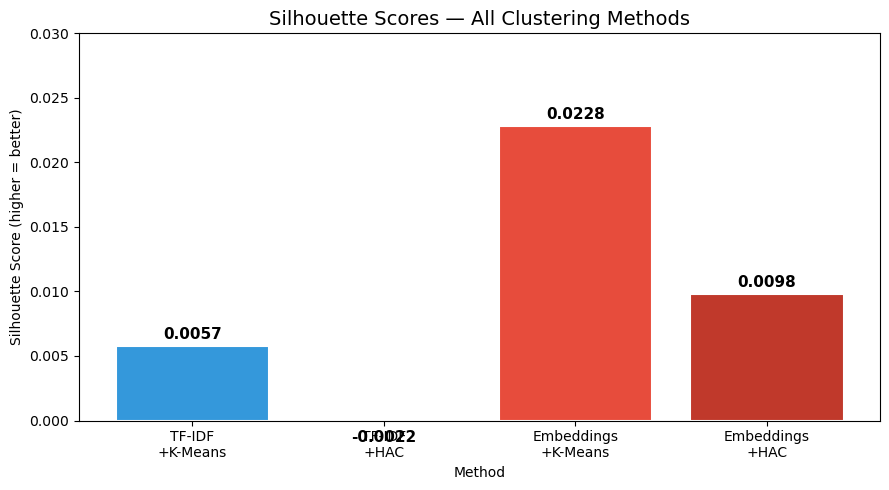

In [9]:
# STEP 6 - VISUALISE RESULTS SUMMARY

methods = ["TF-IDF\n+K-Means", "TF-IDF\n+HAC", "Embeddings\n+K-Means", "Embeddings\n+HAC"]
sscores = [sil_score, sil_hac_tfidf, sil_score_emb, sil_hac_emb]
colors = ["#3498db", "#2980b9", "#e74c3c", "#c0392b"]

plt.figure(figsize=(9, 5))
bars = plt.bar(methods, sscores, color=colors, edgecolor="white", linewidth=1.5)

# Add value labels on top of bars
for bar, score in zip(bars, sscores):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.0003, 
             f"{score:.4f}", 
             ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.title("Silhouette Scores — All Clustering Methods", fontsize=14)
plt.ylabel("Silhouette Score (higher = better)")
plt.xlabel("Method")
plt.ylim(0, 0.03)
plt.tight_layout()
#plt.savefig("../outputs/clustering_comparison.png")
plt.show()

#print(" Plot saved!")

 Creating PCA visualisations...
 Reduced from 384 dimensions → 2 dimensions
   Variance explained: 7.0%


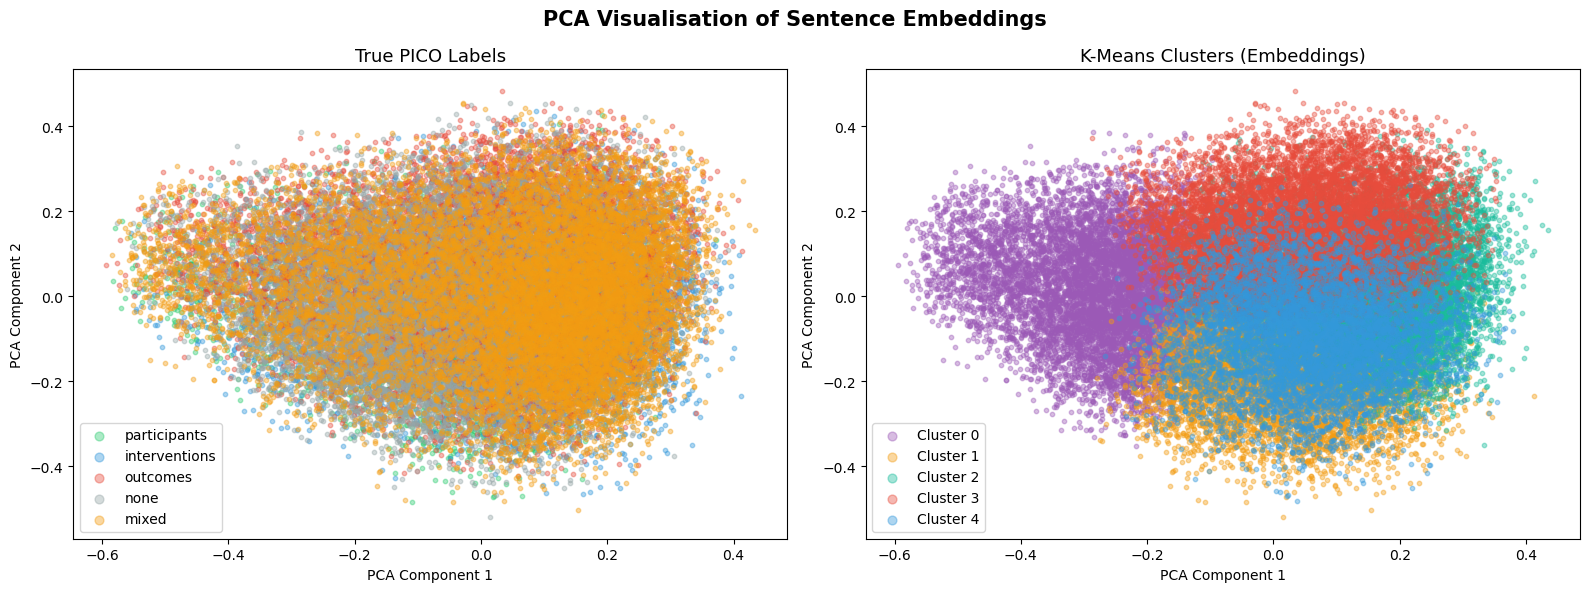

In [10]:
# STEP 7 - PCA VISUALISATION

print(" Creating PCA visualisations...")

# Reduce embeddings to 2D using PCA
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

print(f" Reduced from 384 dimensions → 2 dimensions")
print(f"   Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colour maps
label_colors = {
    "participants": "#2ecc71",
    "interventions": "#3498db", 
    "outcomes": "#e74c3c",
    "none": "#95a5a6",
    "mixed": "#f39c12"
}

# --- Plot 1: Colour by TRUE PICO labels ---
ax1 = axes[0]
for label, color in label_colors.items():
    mask = df["label"] == label
    ax1.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=color, label=label, alpha=0.4, s=10
    )
ax1.set_title("True PICO Labels", fontsize=13)
ax1.legend(markerscale=2)
ax1.set_xlabel("PCA Component 1")
ax1.set_ylabel("PCA Component 2")

# --- Plot 2: Colour by K-MEANS CLUSTERS ---
ax2 = axes[1]
cluster_colors = ["#9b59b6", "#f39c12", "#1abc9c", "#e74c3c","#3498db"]
for cluster in range(5):
    mask = df["kmeans_emb_cluster"] == cluster
    ax2.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        c=cluster_colors[cluster], 
        label=f"Cluster {cluster}", 
        alpha=0.4, s=10
    )
ax2.set_title("K-Means Clusters (Embeddings)", fontsize=13)
ax2.legend(markerscale=2)
ax2.set_xlabel("PCA Component 1")
ax2.set_ylabel("PCA Component 2")

plt.suptitle("PCA Visualisation of Sentence Embeddings", fontsize=15, fontweight="bold")
plt.tight_layout()
#plt.savefig("../outputs/pca_visualisation.png", dpi=150)
plt.show()

#print(" Plot saved!")

 NMI SCORES (how well clusters match PICO labels)
   0.0 = no match, 1.0 = perfect match
-------------------------------------------------------
TF-IDF     + K-Means : 0.0395
TF-IDF     + HAC     : 0.0331
Embeddings + K-Means : 0.0348
Embeddings + HAC     : 0.0274


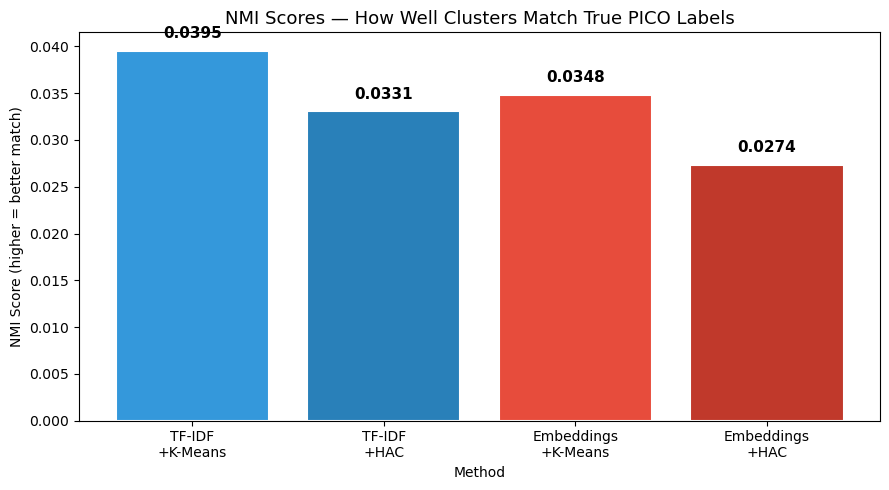

In [11]:
# STEP 8 - COMPARE CLUSTERS TO TRUE LABELS

from sklearn.metrics import normalized_mutual_info_score

# Convert text labels to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
true_labels = le.fit_transform(df["label"])

# Calculate NMI for each method
nmi_kmeans_tfidf = normalized_mutual_info_score(true_labels, tfidf_clusters)
nmi_kmeans_emb = normalized_mutual_info_score(true_labels, emb_clusters)
nmi_hac_tfidf = normalized_mutual_info_score(true_labels[sample_idx], hac_tfidf_clusters)
nmi_hac_emb = normalized_mutual_info_score(true_labels[sample_idx], hac_emb_clusters)

print("="*55)
print(" NMI SCORES (how well clusters match PICO labels)")
print("="*55)
print("   0.0 = no match, 1.0 = perfect match")
print("-"*55)
print(f"TF-IDF     + K-Means : {nmi_kmeans_tfidf:.4f}")
print(f"TF-IDF     + HAC     : {nmi_hac_tfidf:.4f}")
print(f"Embeddings + K-Means : {nmi_kmeans_emb:.4f}")
print(f"Embeddings + HAC     : {nmi_hac_emb:.4f}")
print("="*55)

# Plot NMI scores
methods = ["TF-IDF\n+K-Means", "TF-IDF\n+HAC", "Embeddings\n+K-Means", "Embeddings\n+HAC"]
nmi_scores = [nmi_kmeans_tfidf, nmi_hac_tfidf, nmi_kmeans_emb, nmi_hac_emb]
colors = ["#3498db", "#2980b9", "#e74c3c", "#c0392b"]

plt.figure(figsize=(9, 5))
bars = plt.bar(methods, nmi_scores, color=colors, edgecolor="white", linewidth=1.5)

for bar, score in zip(bars, nmi_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f"{score:.4f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.title("NMI Scores — How Well Clusters Match True PICO Labels", fontsize=13)
plt.ylabel("NMI Score (higher = better match)")
plt.xlabel("Method")
plt.tight_layout()
#plt.savefig("../outputs/nmi_scores.png", dpi=150)
plt.show()

#print(" Plot saved!")

 WHAT IS EACH CLUSTER ABOUT?
(Showing top words and most common true label per cluster)

 K-Means TF-IDF

  Cluster 0 (28205 sentences)
  Most common true label: outcomes (28.4%)
  Label distribution: {'outcomes': 8024, 'none': 7940, 'mixed': 7139, 'interventions': 3693, 'participants': 1409}

  Cluster 1 (6626 sentences)
  Most common true label: mixed (40.9%)
  Label distribution: {'mixed': 2712, 'outcomes': 1081, 'none': 1063, 'participants': 1035, 'interventions': 735}

  Cluster 2 (2374 sentences)
  Most common true label: mixed (48.1%)
  Label distribution: {'mixed': 1142, 'none': 554, 'interventions': 419, 'participants': 220, 'outcomes': 39}

  Cluster 3 (3765 sentences)
  Most common true label: outcomes (36.5%)
  Label distribution: {'outcomes': 1376, 'mixed': 1066, 'none': 634, 'interventions': 551, 'participants': 138}

  Cluster 4 (1511 sentences)
  Most common true label: mixed (39.9%)
  Label distribution: {'mixed': 603, 'interventions': 568, 'none': 169, 'outcomes': 149

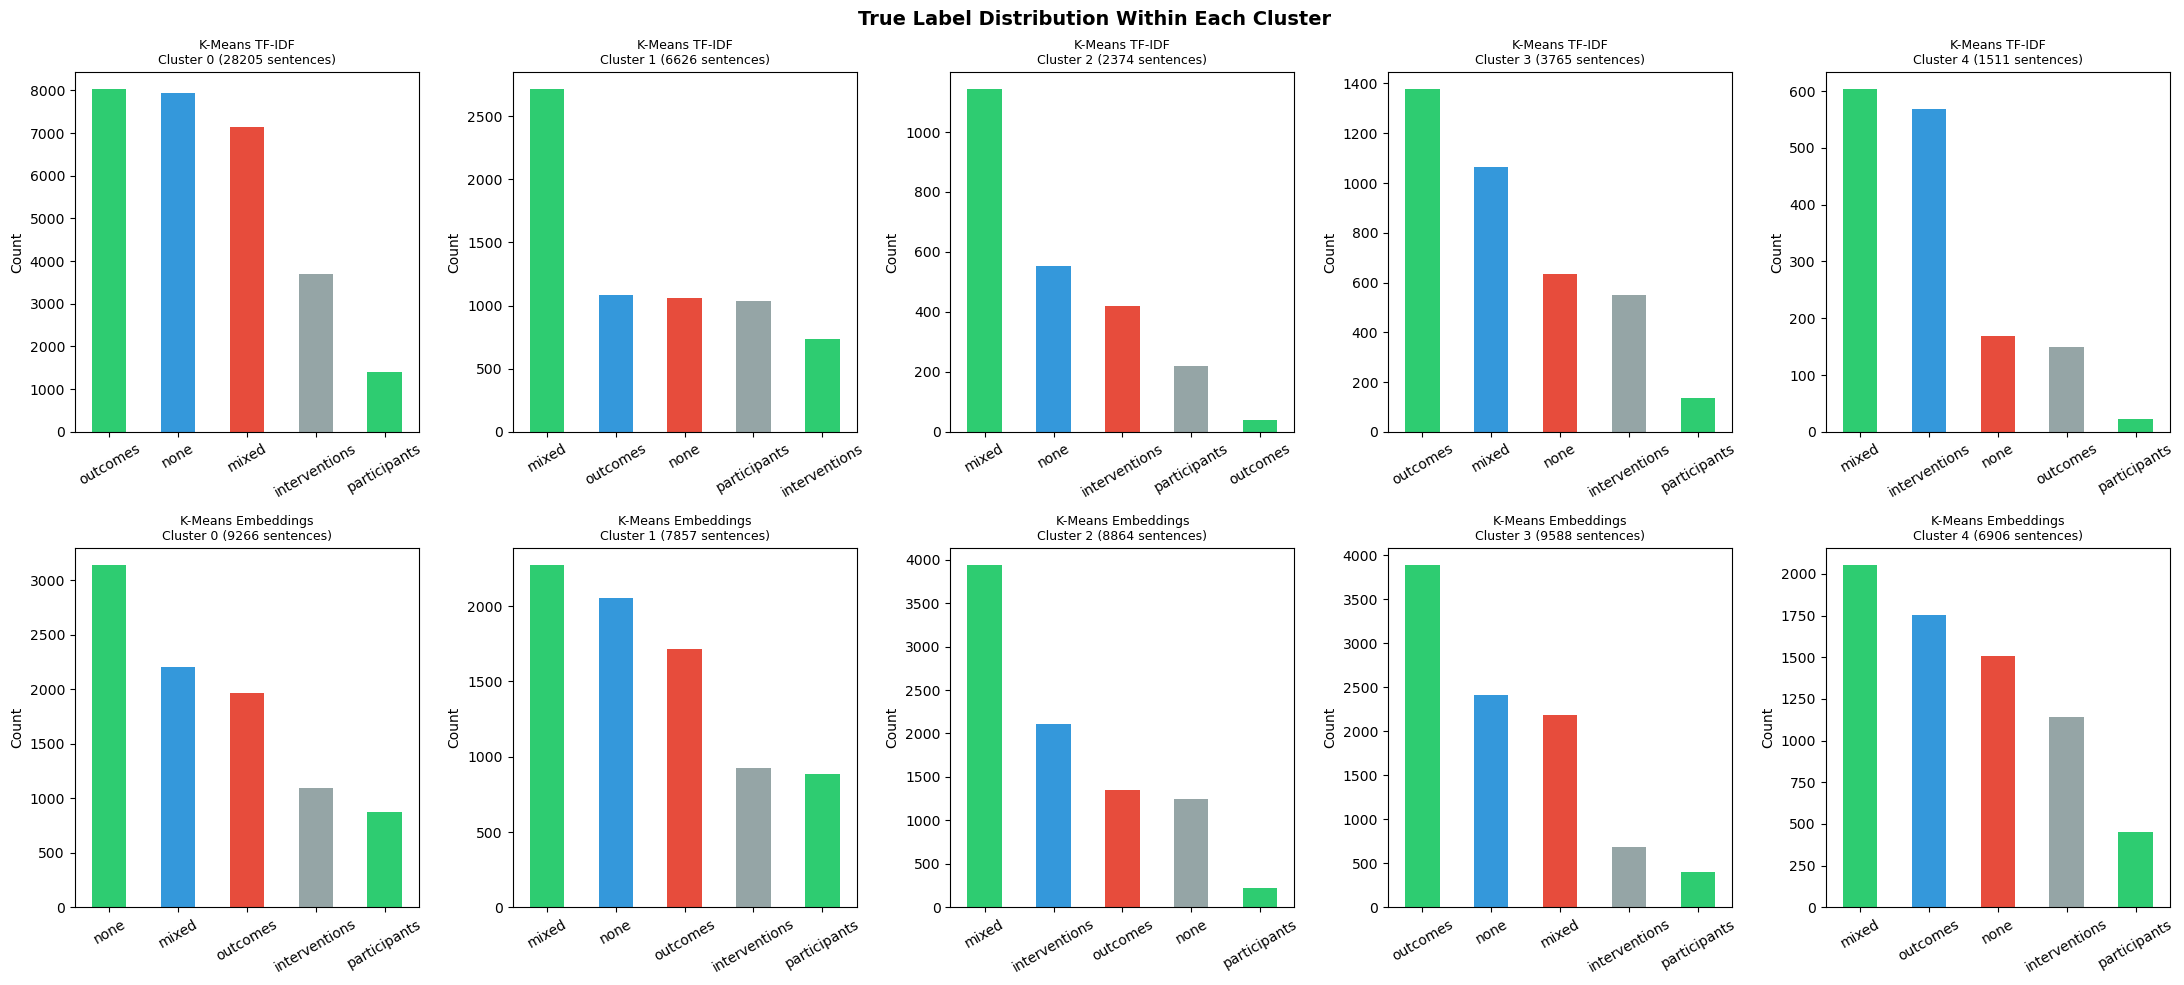

In [12]:
# STEP 9 - WHAT IS EACH CLUSTER ABOUT?

print(" WHAT IS EACH CLUSTER ABOUT?")
print("(Showing top words and most common true label per cluster)\n")

fig, axes = plt.subplots(2, 5, figsize=(22, 10))

for method_name, cluster_col in [("K-Means TF-IDF", "kmeans_tfidf_cluster"), 
                                   ("K-Means Embeddings", "kmeans_emb_cluster")]:
    print(f"{'='*60}")
    print(f" {method_name}")
    print(f"{'='*60}")
    
    row = 0 if method_name == "K-Means TF-IDF" else 1
    
    for cluster in range(5):
        cluster_sentences = df[df[cluster_col] == cluster]["sentence"].tolist()
        cluster_labels = df[df[cluster_col] == cluster]["label"].value_counts()
        
        # Most common true label in this cluster
        dominant_label = cluster_labels.index[0]
        dominant_pct = cluster_labels.iloc[0] / cluster_labels.sum() * 100
        
        print(f"\n  Cluster {cluster} ({len(cluster_sentences)} sentences)")
        print(f"  Most common true label: {dominant_label} ({dominant_pct:.1f}%)")
        print(f"  Label distribution: {cluster_labels.to_dict()}")
        
        # Plot label distribution for this cluster
        ax = axes[row][cluster]
        cluster_labels.plot(kind="bar", ax=ax, 
                          color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6"][:len(cluster_labels)])
        ax.set_title(f"{method_name}\nCluster {cluster} ({len(cluster_sentences)} sentences)", 
                    fontsize=9)
        ax.set_xlabel("")
        ax.tick_params(axis='x', rotation=30)
        ax.set_ylabel("Count")
    
    print()

plt.suptitle("True Label Distribution Within Each Cluster", fontsize=14, fontweight="bold")
plt.tight_layout()
#plt.savefig("../outputs/cluster_composition.png", dpi=150)
plt.show()
#print(" Plot saved!")


In [13]:
# STEP 10 - FINAL SUMMARY

print("="*65)
print(" COMPLETE CLUSTERING ANALYSIS SUMMARY")
print("="*65)

summary_data = {
    "Method": [
        "TF-IDF + K-Means",
        "TF-IDF + HAC",
        "Embeddings + K-Means",
        "Embeddings + HAC"
    ],
    "Silhouette Score": [
        round(sil_score, 4),
        round(sil_hac_tfidf, 4),
        round(sil_score_emb, 4),
        round(sil_hac_emb, 4)
    ],
    "NMI Score": [
        round(nmi_kmeans_tfidf, 4),
        round(nmi_hac_tfidf, 4),
        round(nmi_kmeans_emb, 4),
        round(nmi_hac_emb, 4)
    ]
    # ,
    # "Balanced Clusters?": ["No", "No", "Yes", "Yes"],
    # "Best For": [
    #     "Keyword-based separation",
    #     "Hierarchical structure",
    #     "Semantic grouping",
    #     "Semantic hierarchy"
    # ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# print("\n KEY FINDINGS:")
# print("-"*65)
# print("1. All methods produced low silhouette scores (near 0)")
# print("   → PICO categories are NOT naturally separable by clustering")
# print()
# print("2. Embeddings produced more balanced clusters than TF-IDF")
# print("   → Semantic representations are superior to keyword matching")
# print()
# print("3. K-Means outperformed HAC on both representations")
# print("   → K-Means better suited for this type of text data")
# print()
# print("4. Outcomes dominated all clusters (dataset imbalance effect)")
# print("   → Class imbalance is a key challenge for this task")
# print()
# print(f"5. PCA showed only {pca.explained_variance_ratio_.sum()*100:.1f}% variance explained in 2D")
# print("   → PICO structure exists in higher dimensions, not visible in 2D")
# print()
# print(" CONCLUSION:")
# print("-"*65)
# print("Unsupervised clustering alone is insufficient for PICO extraction.")
# print("Supervised methods (e.g. fine-tuned BERT) will likely be needed.")

# # Save summary
# summary_df.to_csv("../outputs/clustering_summary.csv", index=False)
# print("\n Summary saved to outputs/clustering_summary.csv")

 COMPLETE CLUSTERING ANALYSIS SUMMARY
              Method  Silhouette Score  NMI Score
    TF-IDF + K-Means            0.0057     0.0395
        TF-IDF + HAC           -0.0022     0.0331
Embeddings + K-Means            0.0228     0.0348
    Embeddings + HAC            0.0098     0.0274
